# Projekt 1 - Odporna regresja porządkowa (UTA)
## Zarządzanie odpadami radioaktywnymi

**Pary wariantów:** (4, 9) oraz (12, 19)  
**Grupy informacji preferencyjnej:** 1 i 2

- **Grupa 1:** Wydajność produkcji energii elektrycznej wzrośnie w przyszłości. Dodatkowo nie chcę brać pożyczek.
- **Grupa 2:** Wyczerpywanie się złóż materiałów radioaktywnych → zwiększenie ilości odpadów radioaktywnych.


## Importy i wczytanie danych

In [3]:
import pandas as pd
import numpy as np
from pulp import (
    LpProblem, LpVariable, LpMaximize, LpMinimize,
    lpSum, value, LpStatus, PULP_CBC_CMD
)
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product as iter_product

In [4]:
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
df.index = df.index - 1
df.index.name = 'Variant'

def decode(idx):
    site = idx // 9 + 1
    time = (idx % 9) // 3 + 1
    finance = idx % 3 + 1
    return f'R{site}-S{time}-F{finance}'

df.insert(0, 'Scenario', [decode(i) for i in range(27)])
df

,Scenario,C1,C2,C3,C4
Variant,,,,,
0,R1-S1-F1,0.60,0.93,0.00,0.73
1,R1-S1-F2,0.66,0.55,0.45,0.49
2,R1-S1-F3,1.00,0.45,0.57,0.50
3,R1-S2-F1,0.48,0.87,0.00,0.75
4,R1-S2-F2,0.62,0.40,0.56,0.50
5,R1-S2-F3,0.78,0.27,0.71,0.50
6,R1-S3-F1,0.40,0.90,0.00,0.82
7,R1-S3-F2,0.64,0.44,0.54,0.54
8,R1-S3-F3,0.65,0.30,0.71,0.55


##Kryteria

Wszystkie 4 kryteria (C1–C4) są kosztowe, więc niższe wartości są korzystniejsze.
Z artykułu wynika,że dane są już znormalizowane w oryginalnym zbiorze, więc nie stosujemy dodatkowej normalizacji.

In [5]:
criteria = ['C1', 'C2', 'C3', 'C4']

# Zakresy danych per kryterium (bez dodatkowej normalizacji)
data_ranges = {}
for c in criteria:
    data_ranges[c] = (df[c].min(), df[c].max())
    print(f'{c}: min={df[c].min():.4f}, max={df[c].max():.4f}')

print(f'\nWszystkie kryteria kosztowe (niższy = lepszy)')
print(f'Dane już znormalizowane w źródle — używamy wartości bezpośrednio')

C1: min=0.3200, max=1.0000
C2: min=0.0300, max=1.0000
C3: min=0.0000, max=1.0000
C4: min=0.4900, max=1.0000

Wszystkie kryteria kosztowe (niższy = lepszy)
Dane już znormalizowane w źródle — używamy wartości bezpośrednio


## 3. Informacja preferencyjna

Celem analizy jest stworzenie rankingu 27 scenariuszy w oparciu o wytyczne dwóch grup informacji preferencyjnych.

-**Pierwsza grupa:** Wydajność produkcji energii elektrycznej wzrośnie w przyszłości.
Dodatkowo nie
chcę brać pożyczek. (skupiamy się na kryteriach C 1 i C3)

-**Druga grupa:** W skutek wyczerpywania się złóż materiałów radioaktywnych, elektrownie mogą
zacząć korzystać z bardziej ubogich złóż, co przełoży się na zwiększenie ilości odpadów radioaktywnych. (C2)

 Wszystkie kryteria (C1, C2, C3, C4) są traktowane jako koszt.

### Przydzielone pary:
1. **(9, 4)** → R2-S1-F1 vs R1-S2-F2
2. **(12, 19)** → R2-S2-F1 vs R3-S1-F1

### Ograniczneia

- **Minimalna waga każdego kryterium (0.1):** Każdemu z czterech kryteriów przypisano minimalną wagę 0.1.
- **Ograniczenia anty-trywialności:** Aby uniknąć płaskich funkcji użyteczności, wprowadzono wymóg, by każdy z 4 segmentów cząstkowej funkcji użyteczności generował spadek o wielkości co najmniej 10% całkowitej wagi danego kryterium ($u_i(g_j) - u_i(g_{j+1}) \ge 0.1 \cdot w_i$).
- **Normalizacja:** Suma wag wszystkich kryteriów wynosi dokładnie 1.0

In [6]:
SEED = 42
np.random.seed(SEED)

assigned = {(4, 9), (9, 4), (12, 19), (19, 12)}

candidates = []
while len(candidates) < 3:
    a, b = np.random.choice(27, 2, replace=False)
    pair = (min(a, b), max(a, b))
    if  pair not in assigned and pair not in candidates:
        candidates.append(pair)

# Kierunek preferencji na podstawie sumy C1+C2+C3 (ze względu na przydzielone nam grupy informacji preferencyjnej)
def pair_direction(a, b):
    sa = df.loc[a, ['C1', 'C2', 'C3']].astype(float).sum()
    sb = df.loc[b, ['C1', 'C2', 'C3']].astype(float).sum()
    return (a, b) if sa < sb else (b, a)

preference_pairs = [
    pair_direction(9, 4),       # przydzielona para 1
    pair_direction(12, 19),     # przydzielona para 2
] + [pair_direction(a, b) for a, b in candidates]  # dodatkowe 3 wylosowane pary

print(f'Seed: {SEED}')
print(f'Liczba par referencyjnych: {len(preference_pairs)}')
for better, worse in preference_pairs:
    b_vals = df.loc[better, criteria].values.astype(float)
    w_vals = df.loc[worse, criteria].values.astype(float)
    b_sum = b_vals[:3].sum()
    w_sum = w_vals[:3].sum()
    print(f'  V{better} > V{worse}: sum(C1-C3)={b_sum:.3f} vs {w_sum:.3f}  |  {np.round(b_vals, 3)} vs {np.round(w_vals, 3)}')

Seed: 42
Liczba par referencyjnych: 5
  V9 > V4: sum(C1-C3)=1.310 vs 1.580  |  [0.45 0.86 0.   0.73] vs [0.62 0.4  0.56 0.5 ]
  V12 > V19: sum(C1-C3)=1.450 vs 1.670  |  [0.48 0.97 0.   0.91] vs [0.64 0.22 0.81 0.65]
  V8 > V13: sum(C1-C3)=1.660 vs 1.740  |  [0.65 0.3  0.71 0.55] vs [0.69 0.49 0.56 0.61]
  V22 > V7: sum(C1-C3)=1.530 vs 1.620  |  [0.59 0.24 0.7  0.63] vs [0.64 0.44 0.54 0.54]
  V0 > V25: sum(C1-C3)=1.530 vs 1.840  |  [0.6  0.93 0.   0.73] vs [0.71 0.25 0.88 0.67]


## 4. Funkcje pomocnicze UTA

In [7]:
NUM_BREAKPOINTS = 5
MIN_WEIGHT = 0.1

# Breakpointy per kryterium — na rzeczywistym zakresie danych
# Dla kryterium kosztowego: bp[0]=min (najlepsza) ... bp[-1]=max (najgorsza)
breakpoints = {}
for c in criteria:
    mn, mx = data_ranges[c]
    breakpoints[c] = np.linspace(mn, mx, NUM_BREAKPOINTS)
    print(f'{c}: {np.round(breakpoints[c], 4)}')


def interpolate_utility(x, bp, u_vars):
    """Interpolacja liniowa użyteczności dla wartości x na skali kryterium."""
    for i in range(len(bp) - 1):
        if bp[i] <= x <= bp[i + 1]:
            t = (x - bp[i]) / (bp[i + 1] - bp[i])
            return u_vars[i] + t * (u_vars[i + 1] - u_vars[i])
    # Wartości graniczne
    if x <= bp[0]:
        return u_vars[0]
    return u_vars[-1]


def compute_global_utility(variant_idx, u_vars):
    """Oblicz globalną użyteczność wariantu jako sumę cząstkowych."""
    total = 0
    for c in criteria:
        x = df.loc[variant_idx, c]
        total += interpolate_utility(x, breakpoints[c], u_vars[c])
    return total


def add_uta_constraints(prob, u_vars, name_prefix=''):
    """Dodaj ograniczenia UTA dla kryteriów kosztowych (malejąca użyteczność)."""
    for c in criteria:
        # u(max) = 0 — najgorsza wartość ma zerową użyteczność (wszystkie kryteria są typu koszt)
        prob += u_vars[c][-1] == 0, f'{name_prefix}Zero_{c}'
        # Monotoniczność malejąca + anty-trywialność:
        # każdy segment spada o co najmniej 10% wagi kryterium
        for i in range(NUM_BREAKPOINTS - 1):
            prob += (u_vars[c][i] - u_vars[c][i + 1] >= 0.1 * u_vars[c][0],
                     f'{name_prefix}StrictMono_{c}_{i}')
        # Minimalna waga kryterium: u(min) >= MIN_WEIGHT
        prob += u_vars[c][0] >= MIN_WEIGHT, f'{name_prefix}MinW_{c}'

    # Normalizacja: suma wag (= suma u(min) per kryterium) = 1
    prob += lpSum(u_vars[c][0] for c in criteria) == 1, f'{name_prefix}NormSum'


def create_utility_vars(prefix='u'):
    return {
        c: [LpVariable(f'{prefix}_{c}_{i}', lowBound=0, upBound=1)
            for i in range(NUM_BREAKPOINTS)]
        for c in criteria
    }

print(f'\nKryteria kosztowe → u(min)=waga, u(max)=0, monotoniczność malejąca')
print(f'Anty-trywialność: każdy segment >= 10% wagi kryterium')

C1: [0.32 0.49 0.66 0.83 1.  ]
C2: [0.03   0.2725 0.515  0.7575 1.    ]
C3: [0.   0.25 0.5  0.75 1.  ]
C4: [0.49   0.6175 0.745  0.8725 1.    ]

Kryteria kosztowe → u(min)=waga, u(max)=0, monotoniczność malejąca
Anty-trywialność: każdy segment >= 10% wagi kryterium


---
## Zadanie 3: UTA — najbardziej dyskryminująca instancja

Maksymalizujemy epsilon (minimalną odległości między użytecznościami wariantów referencyjnych).

In [8]:
# inicjalizacja problemu optymalizacyjneg

prob = LpProblem('UTA_MostDiscriminating', LpMaximize)
u = create_utility_vars('u')
epsilon = LpVariable('epsilon', lowBound=0)

# Ograniczenia strukturalne UTA
add_uta_constraints(prob, u)

# Ograniczenia preferencyjne: U(lepszy) >= U(gorszy) + epsilon
for idx, (better, worse) in enumerate(preference_pairs):
    prob += (compute_global_utility(better, u) >= compute_global_utility(worse, u) + epsilon,
             f'Pref_{better}_{worse}')

# Cel: maksymalizacja epsilon (najbardziej dyskryminująca instancja)
prob += epsilon

prob.solve(PULP_CBC_CMD(msg=0))
print(f'Status: {LpStatus[prob.status]}')
print(f'Epsilon (max odległość): {value(epsilon):.6f}')

Status: Optimal
Epsilon (max odległość): 0.159746


In [9]:
# Wartości użyteczności wszystkich wariantów
utilities_z3 = {}
for i in range(27):
    u_val = value(compute_global_utility(i, u))
    utilities_z3[i] = u_val

ranking_z3 = sorted(utilities_z3.items(), key=lambda x: x[1], reverse=True)

print('Ranking wariantów (Zadanie 3):')
for pos, (var, util) in enumerate(ranking_z3):
    marker = ' *' if var in [b for b, w in preference_pairs] + [w for b, w in preference_pairs] else ''
    print(f'  {pos+1:2d}. Wariant {var:2d}  U={util:.4f}{marker}')

Ranking wariantów (Zadanie 3):
   1. Wariant  9  U=0.6787 *
   2. Wariant  3  U=0.6715
   3. Wariant  6  U=0.6596
   4. Wariant 21  U=0.6391
   5. Wariant 15  U=0.6252
   6. Wariant 12  U=0.6143 *
   7. Wariant 18  U=0.6104
   8. Wariant  0  U=0.5757 *
   9. Wariant 22  U=0.5118 *
  10. Wariant 19  U=0.4545 *
  11. Wariant  5  U=0.4457
  12. Wariant  8  U=0.4393 *
  13. Wariant 11  U=0.4393
  14. Wariant 23  U=0.4254
  15. Wariant 17  U=0.4205
  16. Wariant 20  U=0.4163
  17. Wariant 25  U=0.4160 *
  18. Wariant 14  U=0.4107
  19. Wariant 26  U=0.4103
  20. Wariant  4  U=0.4035 *
  21. Wariant  7  U=0.3520 *
  22. Wariant 16  U=0.3464
  23. Wariant 10  U=0.3366
  24. Wariant  2  U=0.2858
  25. Wariant  1  U=0.2835
  26. Wariant 13  U=0.2796 *
  27. Wariant 24  U=0.1954


In [10]:
# Wagi kryteriów (= u_c(min_c), najlepsza wartość kryterium)
print('Wagi kryteriów:')
for c in criteria:
    w = value(u[c][0])
    print(f'  {c}: {w:.4f}')

print(f'\nSuma wag: {sum(value(u[c][0]) for c in criteria):.4f}')

print('\nCząstkowe funkcje użyteczności (breakpointy → użyteczność):')
for c in criteria:
    bp = breakpoints[c]
    vals = [value(u[c][i]) for i in range(NUM_BREAKPOINTS)]
    print(f'  {c}: bp={np.round(bp, 3)} → u={[round(v, 4) for v in vals]}')

Wagi kryteriów:
  C1: 0.1977
  C2: 0.3050
  C3: 0.3974
  C4: 0.1000

Suma wag: 1.0000

Cząstkowe funkcje użyteczności (breakpointy → użyteczność):
  C1: bp=[0.32 0.49 0.66 0.83 1.  ] → u=[0.1977, 0.1779, 0.0395, 0.0198, 0.0]
  C2: bp=[0.03  0.272 0.515 0.758 1.   ] → u=[0.305, 0.2745, 0.061, 0.0305, 0.0]
  C3: bp=[0.   0.25 0.5  0.75 1.  ] → u=[0.3974, 0.1192, 0.0795, 0.0397, 0.0]
  C4: bp=[0.49  0.617 0.745 0.872 1.   ] → u=[0.1, 0.09, 0.08, 0.0483, 0.0]


In [11]:
# Sprawdzenie zgodności z informacją preferencyjną
print('Sprawdzenie par preferencji:')
all_ok = True
for better, worse in preference_pairs:
    diff = utilities_z3[better] - utilities_z3[worse]
    ok = 'OK' if diff > 0 else 'FAIL'
    if diff <= 0:
        all_ok = False
    print(f'  {better} ({decode(better)}) > {worse} ({decode(worse)}): '
          f'U={utilities_z3[better]:.4f} vs {utilities_z3[worse]:.4f}, diff={diff:.4f} [{ok}]')
print(f'\nWszystkie pary spełnione: {all_ok}')

Sprawdzenie par preferencji:
  9 (R2-S1-F1) > 4 (R1-S2-F2): U=0.6787 vs 0.4035, diff=0.2752 [OK]
  12 (R2-S2-F1) > 19 (R3-S1-F2): U=0.6143 vs 0.4545, diff=0.1597 [OK]
  8 (R1-S3-F3) > 13 (R2-S2-F2): U=0.4393 vs 0.2796, diff=0.1597 [OK]
  22 (R3-S2-F2) > 7 (R1-S3-F2): U=0.5118 vs 0.3520, diff=0.1597 [OK]
  0 (R1-S1-F1) > 25 (R3-S3-F2): U=0.5757 vs 0.4160, diff=0.1597 [OK]

Wszystkie pary spełnione: True


/tmp/ipykernel_515/1803222331.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


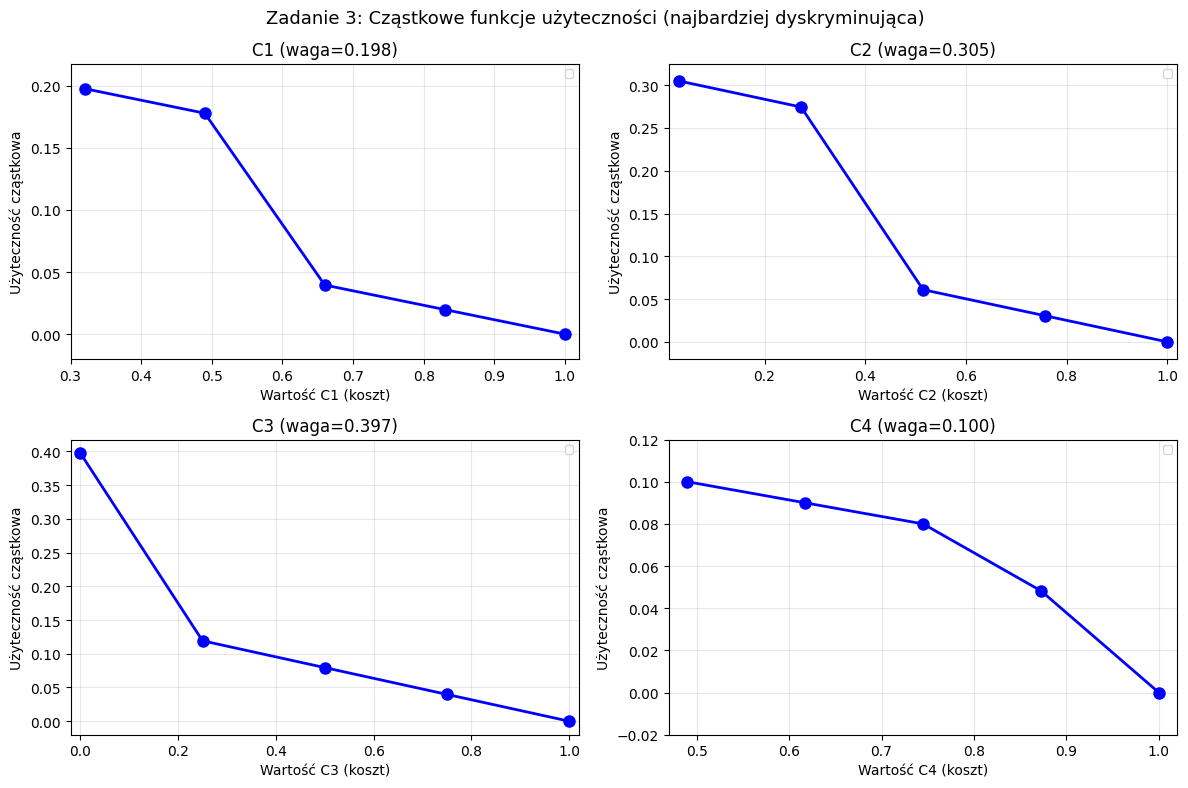

In [12]:
# Wykresy cząstkowych funkcji użyteczności (Zadanie 3)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, c in enumerate(criteria):
    ax = axes[idx // 2][idx % 2]
    bp = breakpoints[c]
    vals = [value(u[c][i]) for i in range(NUM_BREAKPOINTS)]
    ax.plot(bp, vals, 'bo-', linewidth=2, markersize=8)
    ax.set_title(f'{c} (waga={vals[0]:.3f})')
    ax.set_xlabel(f'Wartość {c} (koszt)')
    ax.set_ylabel('Użyteczność cząstkowa')
    ax.set_xlim(bp[0] - 0.02, bp[-1] + 0.02)
    ax.set_ylim(-0.02, max(vals) + 0.02)
    ax.grid(True, alpha=0.3)
    # Zaznacz wartości wariantów na osi X

    ax.legend(fontsize=8)

fig.suptitle('Zadanie 3: Cząstkowe funkcje użyteczności (najbardziej dyskryminująca)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Zadanie 4: UTA-GMS — relacje konieczne i możliwe

Dla każdej pary wariantów (a, b) sprawdzamy:
- **Relacja konieczna** (a ≽_N b): U(a) ≥ U(b) dla WSZYSTKICH zgodnych funkcji użyteczności
- **Relacja możliwa** (a ≽_P b): U(a) ≥ U(b) dla PEWNEJ zgodnej funkcji użyteczności

In [13]:

def check_preference_relation(a_idx, b_idx, relation_type='necessary'):

    #Sprawdzamy relację preferencji między wariantami a i b.
    #relation_type: 'necessary' (min U(a)-U(b) >= 0) lub 'possible' (max U(a)-U(b) >= 0)

    sense = LpMinimize if relation_type == 'necessary' else LpMaximize
    prob = LpProblem(f'{relation_type}_{a_idx}_{b_idx}', sense)

    uv = create_utility_vars(f'r_{a_idx}_{b_idx}')
    add_uta_constraints(prob, uv, f'R_{a_idx}_{b_idx}_')

    # Ograniczenia preferencji referencyjnych
    for idx, (better, worse) in enumerate(preference_pairs):
        u_b = compute_global_utility(better, uv)
        u_w = compute_global_utility(worse, uv)
        prob += u_b >= u_w + 0.001, f'R_{a_idx}_{b_idx}_Pref_{idx}'

    # Cel: min/max U(a) - U(b)
    u_a = compute_global_utility(a_idx, uv)
    u_b_val = compute_global_utility(b_idx, uv)
    prob += u_a - u_b_val

    prob.solve(PULP_CBC_CMD(msg=0))

    if prob.status != 1:
        return None

    return value(prob.objective)

In [14]:
n = 27
necessary = np.zeros((n, n), dtype=bool)
possible = np.zeros((n, n), dtype=bool)

for i in range(n):
    necessary[i][i] = True
    possible[i][i] = True

for i in range(n):
    for j in range(n):
        if i == j:
            continue
        # Necessary: min U(i)-U(j) >= 0
        val_n = check_preference_relation(i, j, 'necessary')
        if val_n is not None and val_n >= -1e-6:
            necessary[i][j] = True

        # Possible: max U(i)-U(j) >= 0
        val_p = check_preference_relation(i, j, 'possible')
        if val_p is not None and val_p >= -1e-6:
            possible[i][j] = True

In [15]:

n_necessary = int(necessary.sum()) - n  # minus diagonal
n_possible = int(possible.sum()) - n
total_pairs = n * (n - 1)

print(f'Relacje konieczne (a ≽_N b): {n_necessary} / {total_pairs} par')
print(f'Relacje możliwe (a ≽_P b):   {n_possible} / {total_pairs} par')

print('\nSprawdzenie par referencyjnych w relacji koniecznej:')
for better, worse in preference_pairs:
    is_nec = necessary[better][worse]
    print(f'  {better} ({decode(better)}) ≽_N {worse} ({decode(worse)}): {is_nec}')

Relacje konieczne (a ≽_N b): 49 / 702 par
Relacje możliwe (a ≽_P b):   653 / 702 par

Sprawdzenie par referencyjnych w relacji koniecznej:
  9 (R2-S1-F1) ≽_N 4 (R1-S2-F2): True
  12 (R2-S2-F1) ≽_N 19 (R3-S1-F2): True
  8 (R1-S3-F3) ≽_N 13 (R2-S2-F2): True
  22 (R3-S2-F2) ≽_N 7 (R1-S3-F2): True
  0 (R1-S1-F1) ≽_N 25 (R3-S3-F2): True


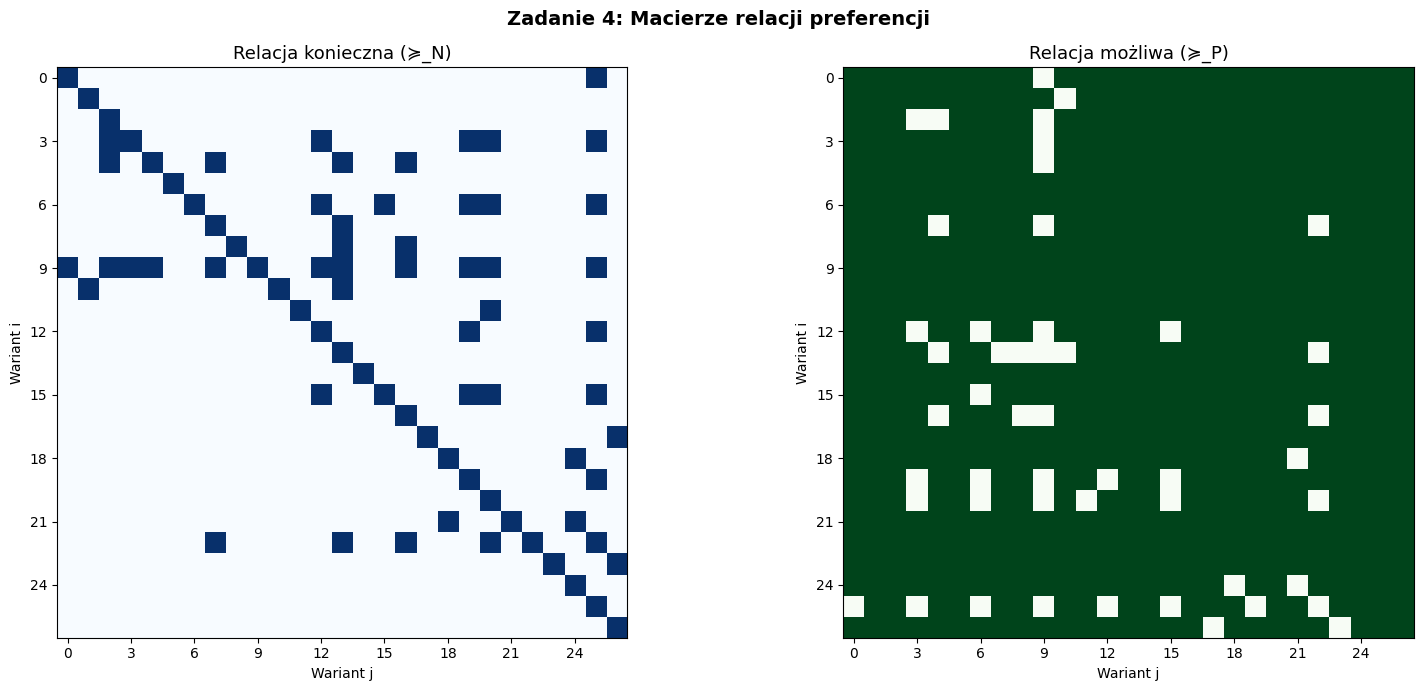

In [16]:
# Macierze relacji - wizualizacja
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.imshow(necessary.astype(int), cmap='Blues', interpolation='nearest')
ax1.set_title('Relacja konieczna (≽_N)', fontsize=13)
ax1.set_xlabel('Wariant j')
ax1.set_ylabel('Wariant i')
ax1.set_xticks(range(0, 27, 3))
ax1.set_yticks(range(0, 27, 3))

ax2.imshow(possible.astype(int), cmap='Greens', interpolation='nearest')
ax2.set_title('Relacja możliwa (≽_P)', fontsize=13)
ax2.set_xlabel('Wariant j')
ax2.set_ylabel('Wariant i')
ax2.set_xticks(range(0, 27, 3))
ax2.set_yticks(range(0, 27, 3))

fig.suptitle('Zadanie 4: Macierze relacji preferencji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('z4_relations.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Diagram Hasse'go dla relacji koniecznej

strict_necessary = np.zeros((n, n), dtype=bool)
for i in range(n):
    for j in range(n):
        if i != j and necessary[i][j] and not necessary[j][i]:
            strict_necessary[i][j] = True


hasse = strict_necessary.copy()
for i in range(n):
    for j in range(n):
        if not hasse[i][j]:
            continue
        for k in range(n):
            if k != i and k != j and strict_necessary[i][k] and strict_necessary[k][j]:
                hasse[i][j] = False
                break


G = nx.DiGraph()
for i in range(n):
    G.add_node(i, label=decode(i))
for i in range(n):
    for j in range(n):
        if hasse[i][j]:
            G.add_edge(i, j)

print(f'Krawędzie diagramu Hasse: {G.number_of_edges()}')
print(f'\nRelacje ścisłe konieczne: {int(strict_necessary.sum())}')

Krawędzie diagramu Hasse: 29

Relacje ścisłe konieczne: 49


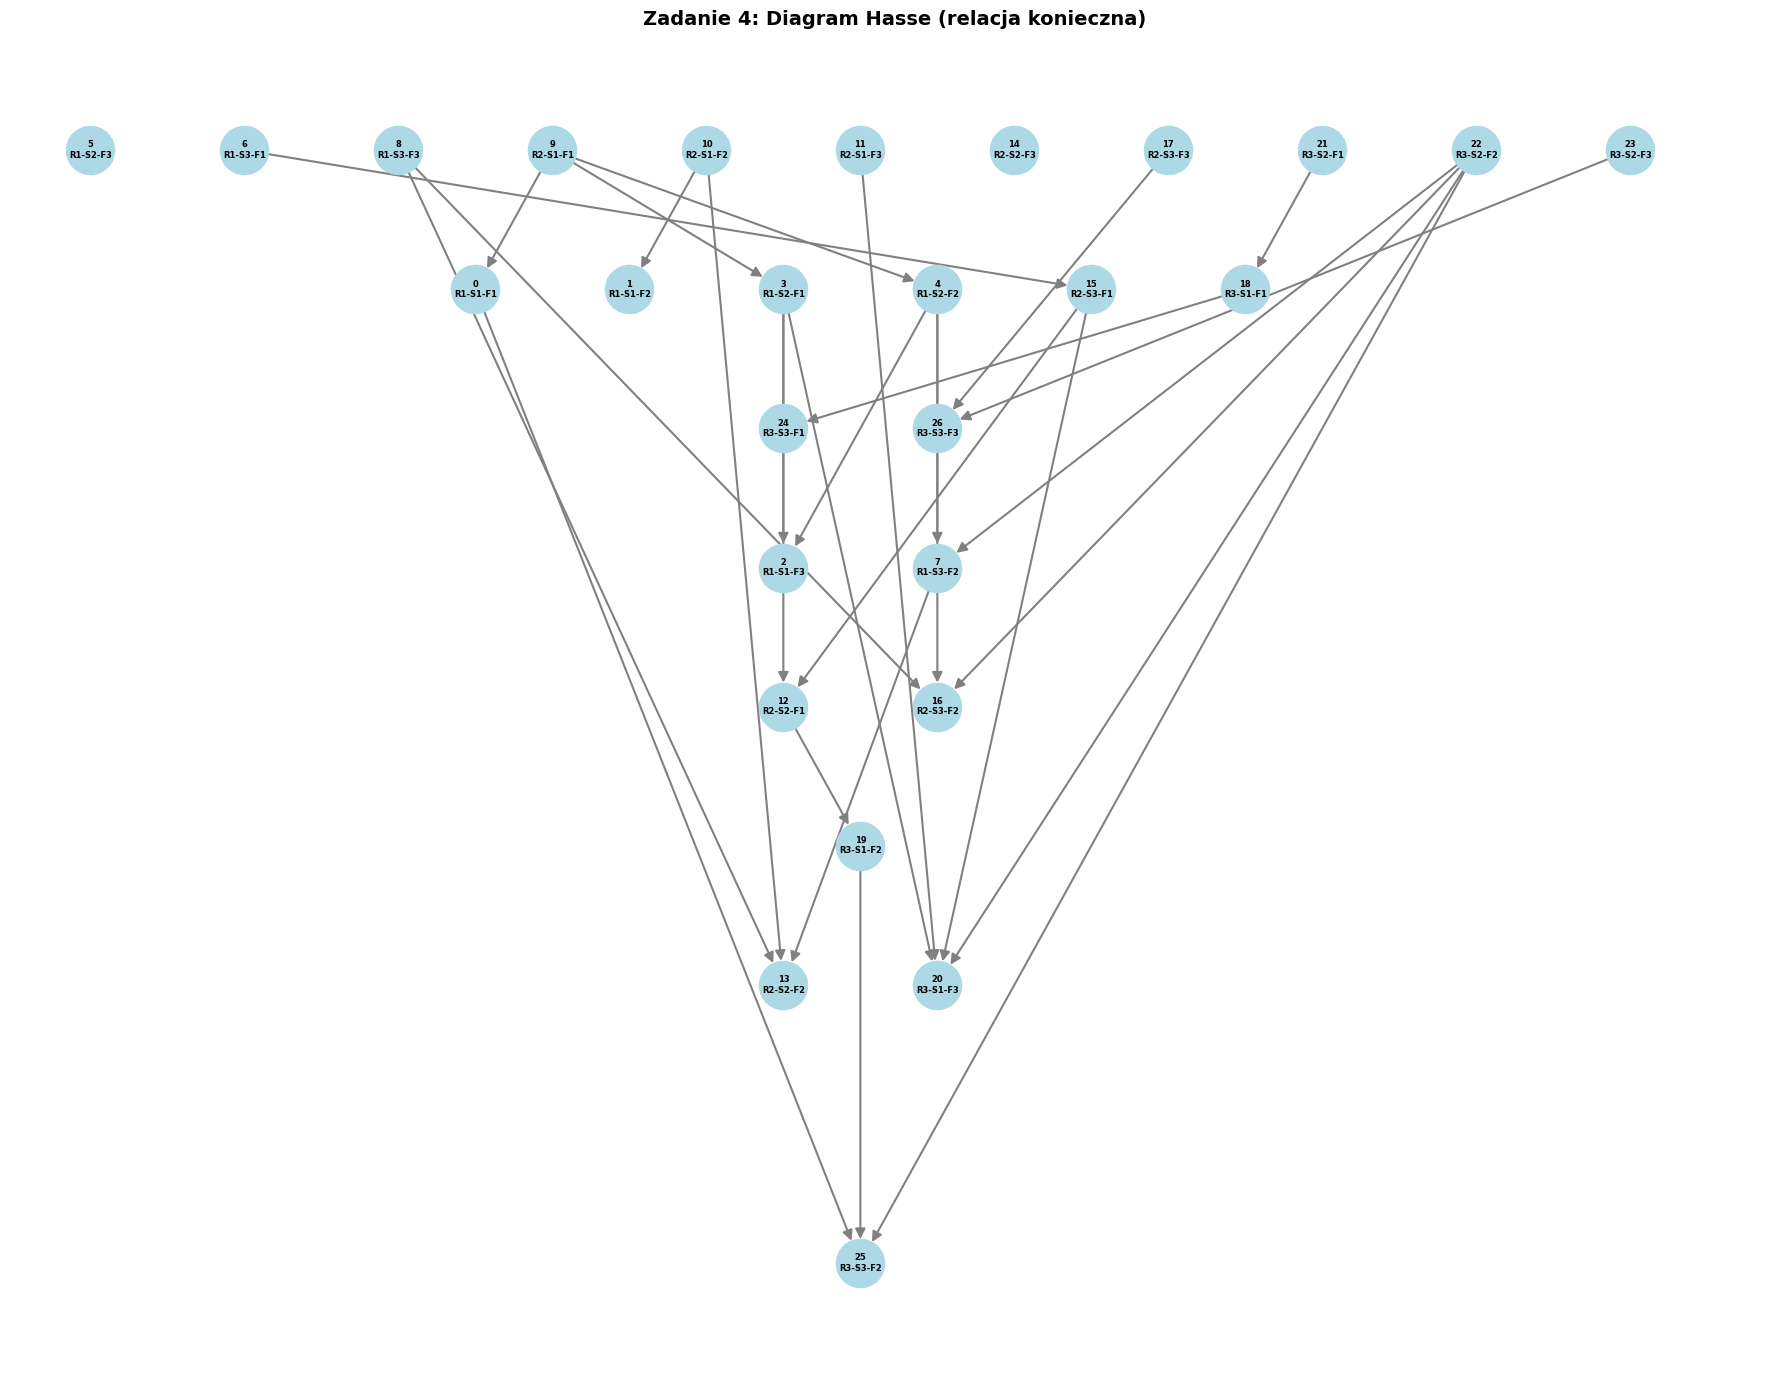

In [18]:
# Rysowanie diagramu Hasse'go


levels = {}
for i in range(n):
    levels[i] = sum(strict_necessary[j][i] for j in range(n))


level_groups = {}
for node, level in levels.items():
    level_groups.setdefault(level, []).append(node)


pos = {}
for level, nodes in sorted(level_groups.items()):
    num = len(nodes)
    for j, node in enumerate(sorted(nodes)):
        x = (j - (num - 1) / 2) * 1.5
        y = -level * 1.2
        pos[node] = (x, y)

fig, ax = plt.subplots(figsize=(18, 14))
node_labels = {i: f'{i}\n{decode(i)}' for i in range(n)}

nx.draw(G, pos, ax=ax,
        labels=node_labels,
        node_color='lightblue',
        node_size=1200,
        font_size=6,
        font_weight='bold',
        arrows=True,
        arrowsize=15,
        edge_color='gray',
        width=1.5)

ax.set_title('Zadanie 4: Diagram Hasse (relacja konieczna)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('z4_hasse.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Opis relacji

# Konieczna indyferencja: a ~_N b iff a >=_N b AND b >=_N a
nec_indiff = []
for i in range(n):
    for j in range(i + 1, n):
        if necessary[i][j] and necessary[j][i]:
            nec_indiff.append((i, j))

print(f'Pary koniecznie indyferentne ({len(nec_indiff)}):')
for a, b in nec_indiff[:20]:
    print(f'  {a} ({decode(a)}) ~ {b} ({decode(b)})')
if len(nec_indiff) > 20:
    print(f'  ... i {len(nec_indiff) - 20} więcej')

# Nieporównywalne w sensie koniecznym: not a >=_N b AND not b >=_N a
incomparable = 0
for i in range(n):
    for j in range(i + 1, n):
        if not necessary[i][j] and not necessary[j][i]:
            incomparable += 1

print(f'\nPary nieporównywalne: {incomparable}')

# Top i bottom wariantów
top = [i for i in range(n) if not any(strict_necessary[j][i] for j in range(n))]
bottom = [i for i in range(n) if not any(strict_necessary[i][j] for j in range(n))]
print(f'\nWarianty na szczycie: {[f"{v} ({decode(v)})" for v in top]}')
print(f'Warianty na dole: {[f"{v} ({decode(v)})" for v in bottom]}')

Pary koniecznie indyferentne (0):

Pary nieporównywalne: 302

Warianty na szczycie: ['5 (R1-S2-F3)', '6 (R1-S3-F1)', '8 (R1-S3-F3)', '9 (R2-S1-F1)', '10 (R2-S1-F2)', '11 (R2-S1-F3)', '14 (R2-S2-F3)', '17 (R2-S3-F3)', '21 (R3-S2-F1)', '22 (R3-S2-F2)', '23 (R3-S2-F3)']
Warianty na dole: ['1 (R1-S1-F2)', '2 (R1-S1-F3)', '5 (R1-S2-F3)', '13 (R2-S2-F2)', '14 (R2-S2-F3)', '16 (R2-S3-F2)', '20 (R3-S1-F3)', '24 (R3-S3-F1)', '25 (R3-S3-F2)', '26 (R3-S3-F3)']


---
## Zadanie 5: Reprezentatywna funkcja użyteczności

Szukamy funkcji użyteczności, która:
1. Jest zgodna z informacją preferencyjną
2. Maksymalnie odzwierciedla relacje konieczne (maksymalizacja sumy różnic U(a)-U(b) dla par koniecznie preferowanych)

In [20]:

prob5 = LpProblem('UTA_Representative', LpMaximize)
u5 = create_utility_vars('u5')
add_uta_constraints(prob5, u5, 'Z5_')

# Ograniczenia preferencji referencyjnych
for idx, (better, worse) in enumerate(preference_pairs):
    u_b = compute_global_utility(better, u5)
    u_w = compute_global_utility(worse, u5)
    prob5 += u_b >= u_w + 0.001, f'Z5_Pref_{idx}'

# Zbierz pary koniecznie preferowane (strict)
nec_strict_pairs = []
for i in range(n):
    for j in range(n):
        if strict_necessary[i][j]:
            nec_strict_pairs.append((i, j))

print(f'Liczba par koniecznie ściśle preferowanych: {len(nec_strict_pairs)}')

# Cel: maksymalizacja sumy różnic dla par koniecznych
if len(nec_strict_pairs) > 0:
    obj_terms = []
    for i, j in nec_strict_pairs:
        u_i = compute_global_utility(i, u5)
        u_j = compute_global_utility(j, u5)
        d = LpVariable(f'z5_d_{i}_{j}', lowBound=0)
        prob5 += d == u_i - u_j, f'Z5_Diff_{i}_{j}'
        prob5 += d >= 0.0001, f'Z5_DiffPos_{i}_{j}'
        obj_terms.append(d)
    prob5 += lpSum(obj_terms)
else:
    eps5 = LpVariable('eps5', lowBound=0)
    for idx, (better, worse) in enumerate(preference_pairs):
        u_b = compute_global_utility(better, u5)
        u_w = compute_global_utility(worse, u5)
        prob5 += u_b >= u_w + eps5, f'Z5_Eps_{idx}'
    prob5 += eps5

prob5.solve(PULP_CBC_CMD(msg=0))
print(f'Status: {LpStatus[prob5.status]}')
print(f'Wartość funkcji celu: {value(prob5.objective):.6f}')

Liczba par koniecznie ściśle preferowanych: 49
Status: Optimal
Wartość funkcji celu: 16.032467


In [21]:


utilities_z5 = {}
for i in range(27):
    u_val = value(compute_global_utility(i, u5))
    utilities_z5[i] = u_val

ranking_z5 = sorted(utilities_z5.items(), key=lambda x: x[1], reverse=True)

print(f'{"Poz":>4} {"Var":>4} {"Scenariusz":>12} {"U(a)":>10}')
print('-' * 35)
for pos, (var, util) in enumerate(ranking_z5, 1):
    marker = ' *' if var in [p[0] for p in preference_pairs] + [p[1] for p in preference_pairs] else ''
    print(f'{pos:4d} {var:4d} {decode(var):>12} {util:10.4f}{marker}')

print('\nWagi kryteriów:')
for c in criteria:
    w = value(u5[c][0])
    print(f'  {c}: {w:.4f}')

print('\nWartości funkcji użyteczności w breakpointach:')
for c in criteria:
    bp = breakpoints[c]
    vals = [value(u5[c][i]) for i in range(NUM_BREAKPOINTS)]
    print(f'  {c}: bp={np.round(bp, 3)} → u={[round(v, 4) for v in vals]}')

 Poz  Var   Scenariusz       U(a)
-----------------------------------
   1    9     R2-S1-F1     0.8469 *
   2    6     R1-S3-F1     0.8445
   3    3     R1-S2-F1     0.8412
   4   21     R3-S2-F1     0.8288
   5   15     R2-S3-F1     0.8233
   6   12     R2-S2-F1     0.8139 *
   7   18     R3-S1-F1     0.8072
   8    0     R1-S1-F1     0.7427 *
   9   10     R2-S1-F2     0.5201
  10    1     R1-S1-F2     0.3608
  11    4     R1-S2-F2     0.3030 *
  12   22     R3-S2-F2     0.2790 *
  13    7     R1-S3-F2     0.2780 *
  14    8     R1-S3-F3     0.2324 *
  15   13     R2-S2-F2     0.2314 *
  16    5     R1-S2-F3     0.2237
  17    2     R1-S1-F3     0.2210
  18   16     R2-S3-F2     0.2179
  19   11     R2-S1-F3     0.2160
  20   19     R3-S1-F2     0.2135 *
  21   24     R3-S3-F1     0.2102
  22   23     R3-S2-F3     0.1990
  23   17     R2-S3-F3     0.1922
  24   14     R2-S2-F3     0.1845
  25   26     R3-S3-F3     0.1785
  26   20     R3-S1-F3     0.1684
  27   25     R3-S3-F2     0

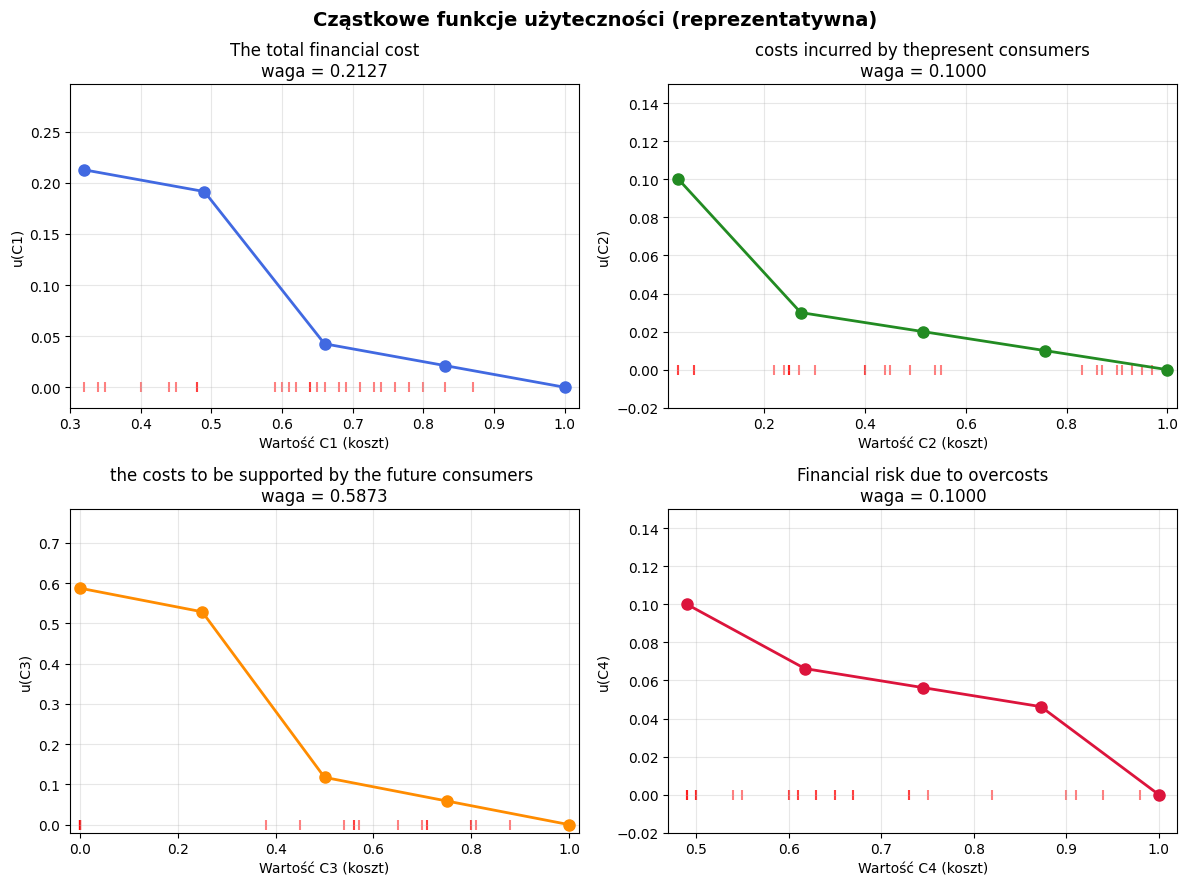

In [22]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for idx, c in enumerate(criteria):
    ax = axes[idx // 2][idx % 2]
    bp = breakpoints[c]
    y5 = [value(u5[c][i]) for i in range(NUM_BREAKPOINTS)]
    colors = ['royalblue', 'forestgreen', 'darkorange', 'crimson']
    ax.plot(bp, y5, 'o-', color=colors[idx], linewidth=2, markersize=8)
    ax.set_xlabel(f'Wartość {c} (koszt)')
    ax.set_ylabel(f'u({c})')
    labels = {
    'C1': 'The total financial cost',
    'C2': 'costs incurred by thepresent consumers',
    'C3': 'the costs to be supported by the future consumers ',
    'C4': 'Financial risk due to overcosts'
}
    ax.set_title(f'{labels[c]}\nwaga = {y5[0]:.4f}')
    ax.set_xlim(bp[0] - 0.02, bp[-1] + 0.02)
    ax.set_ylim(-0.02, max(y5) * 1.3 + 0.02)
    ax.grid(True, alpha=0.3)
    variant_vals = df[c].values
    ax.scatter(variant_vals, [0]*len(variant_vals), marker='|', c='red', s=50, alpha=0.5)

fig.suptitle('Cząstkowe funkcje użyteczności (reprezentatywna)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('z5_utility_functions.png', dpi=150, bbox_inches='tight')
plt.show()

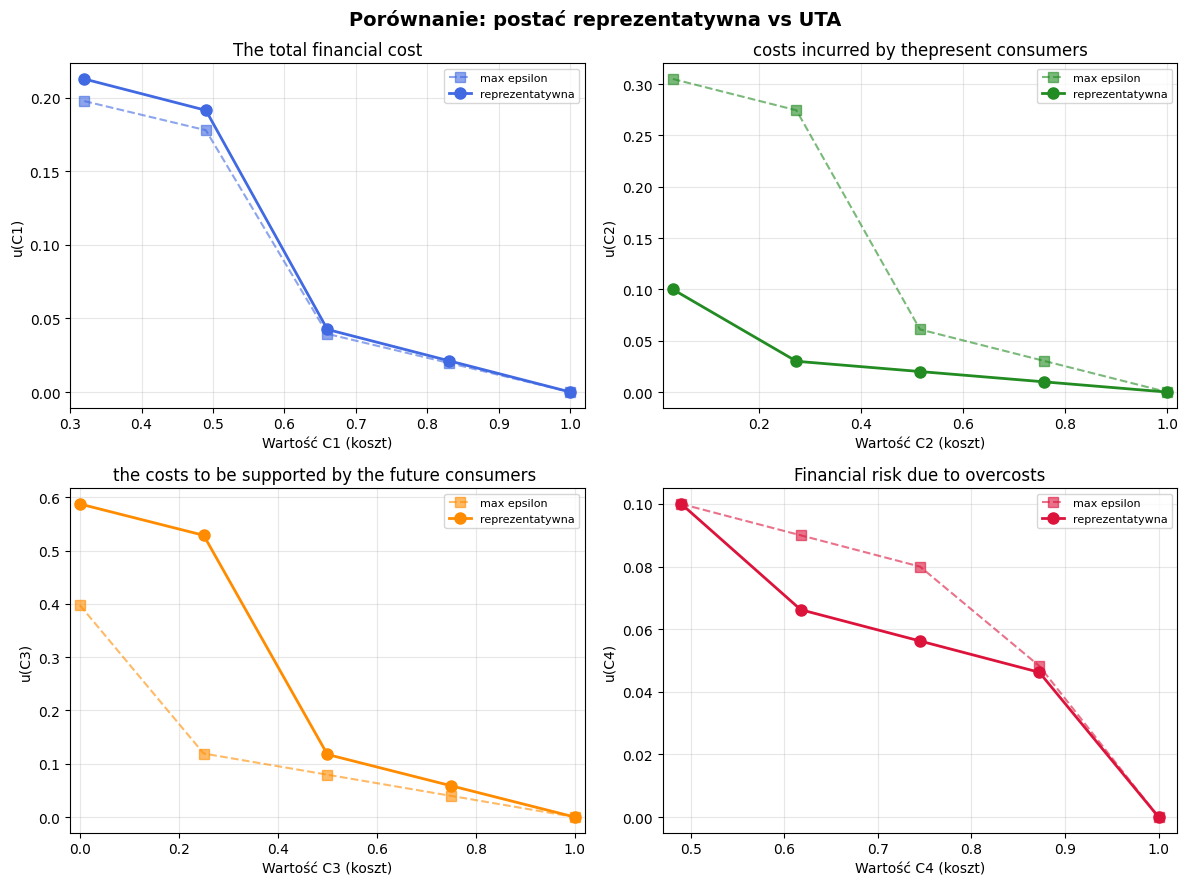

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for idx, c in enumerate(criteria):
    ax = axes[idx // 2][idx % 2]
    bp = breakpoints[c]
    y3 = [value(u[c][i]) for i in range(NUM_BREAKPOINTS)]
    y5 = [value(u5[c][i]) for i in range(NUM_BREAKPOINTS)]
    ax.plot(bp, y3, 's--', color=colors[idx], linewidth=1.5, markersize=7,
            alpha=0.6, label='max epsilon')
    ax.plot(bp, y5, 'o-', color=colors[idx], linewidth=2, markersize=8,
            label='reprezentatywna')
    ax.set_xlabel(f'Wartość {c} (koszt)')
    ax.set_ylabel(f'u({c})')
    ax.set_title(labels[c])
    ax.set_xlim(bp[0] - 0.02, bp[-1] + 0.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Porównanie: postać reprezentatywna vs UTA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('z3_vs_z5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:

rank_z3 = {var: pos for pos, (var, _) in enumerate(ranking_z3, 1)}
rank_z5 = {var: pos for pos, (var, _) in enumerate(ranking_z5, 1)}

print(f'{"Var":>4} {"Scenariusz":>12} {"Poz.Z3":>8} {"U(Z3)":>8} {"Poz.Z5":>8} {"U(Z5)":>8} {"Zmiana":>8}')
print('-' * 60)
for var in range(27):
    change = rank_z3[var] - rank_z5[var]
    arrow = '+' + str(abs(change)) if change > 0 else str(change) if change < 0 else '='
    print(f'{var:4d} {decode(var):>12} {rank_z3[var]:8d} {utilities_z3[var]:8.4f} '
          f'{rank_z5[var]:8d} {utilities_z5[var]:8.4f} {arrow:>8}')



 Var   Scenariusz   Poz.Z3    U(Z3)   Poz.Z5    U(Z5)   Zmiana
------------------------------------------------------------
   0     R1-S1-F1        8   0.5757        8   0.7427        =
   1     R1-S1-F2       25   0.2835       10   0.3608      +15
   2     R1-S1-F3       24   0.2858       17   0.2210       +7
   3     R1-S2-F1        2   0.6715        3   0.8412       -1
   4     R1-S2-F2       20   0.4035       11   0.3030       +9
   5     R1-S2-F3       11   0.4457       16   0.2237       -5
   6     R1-S3-F1        3   0.6596        2   0.8445       +1
   7     R1-S3-F2       21   0.3520       13   0.2780       +8
   8     R1-S3-F3       12   0.4393       14   0.2324       -2
   9     R2-S1-F1        1   0.6787        1   0.8469        =
  10     R2-S1-F2       23   0.3366        9   0.5201      +14
  11     R2-S1-F3       13   0.4393       19   0.2160       -6
  12     R2-S2-F1        6   0.6143        6   0.8139        =
  13     R2-S2-F2       26   0.2796       15   0.2314    